In [24]:
# ============================================================
# İSTANBUL 39 İLÇE SU TÜKETİM TAHMİNİ - XGBoost
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır
# Eğitim: 2020-01 → 2024-12  |  Tahmin: 2025-01 → 2025-10
#
# XGBoost yaklaşımı (LightGBM ile aynı strateji):
#   Özellikler: lag, rolling, takvim + exogenous
#   Strateji  : recursive (adım adım 10 ay ileriye tahmin)
#   Fark      : XGBoost level-wise büyür (LightGBM leaf-wise)
#               → genellikle daha yavaş ama daha sağlam
# ============================================================

# ── AŞAMA 1: KÜTÜPHANELERİ İÇE AKTAR ──────────────────────
# Kurulum: pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

print("✅ Kütüphaneler yüklendi")
print(f"   XGBoost: {xgb.__version__}")

✅ Kütüphaneler yüklendi
   XGBoost: 3.2.0


In [25]:
# ── AŞAMA 2: DOSYA YOLLARI ─────────────────────────────────
ABONE_DOSYA    = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\abone.xlsx"
SU_DOSYA       = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\su_tuketim.xlsx"
SICAKLIK_DOSYA = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\sicaklik.xlsx"

In [26]:
# ── AŞAMA 3: YARDIMCI FONKSİYON - TARİH PARSE ─────────────
AYLAR_TR = {
    "Ocak":1, "Şubat":2, "Mart":3, "Nisan":4,
    "Mayıs":5, "Haziran":6, "Temmuz":7, "Ağustos":8,
    "Eylül":9, "Ekim":10, "Kasım":11, "Aralık":12
}

def tarih_parse(tarih_str):
    parcalar = str(tarih_str).strip().split()
    yil = int(parcalar[0])
    ay  = AYLAR_TR[parcalar[-1]]
    return pd.Timestamp(year=yil, month=ay, day=1)

In [27]:
# ── AŞAMA 4: ABONE VERİSİNİ YÜKLE ──────────────────────────
abone_raw = pd.read_excel(ABONE_DOSYA, header=1)

konut = abone_raw.iloc[:, 0:3].copy()
konut.columns = ["ilce", "tarih", "konut_abone"]

isyeri = abone_raw.iloc[:, 8:11].copy()
isyeri.columns = ["ilce", "tarih", "isyeri_abone"]

konut  = konut.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri = isyeri.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut["tarih"]  = konut["tarih"].apply(tarih_parse)
isyeri["tarih"] = isyeri["tarih"].apply(tarih_parse)

abone_df = pd.merge(konut, isyeri, on=["ilce", "tarih"], how="outer")
abone_df = abone_df[["ilce", "tarih", "konut_abone", "isyeri_abone"]]

print(f"✅ Abone verisi: {abone_df.shape[0]} satır, {abone_df['ilce'].nunique()} ilçe")

✅ Abone verisi: 2808 satır, 39 ilçe


In [28]:
# ── AŞAMA 5: SU TÜKETİM VERİSİNİ YÜKLE ────────────────────
su_raw = pd.read_excel(SU_DOSYA, header=1)

konut_su = su_raw.iloc[:, 0:3].copy()
konut_su.columns = ["ilce", "tarih", "konut_m3"]

isyeri_su = su_raw.iloc[:, 4:7].copy()
isyeri_su.columns = ["ilce", "tarih", "isyeri_m3"]

konut_su  = konut_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri_su = isyeri_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut_su["tarih"]  = konut_su["tarih"].apply(tarih_parse)
isyeri_su["tarih"] = isyeri_su["tarih"].apply(tarih_parse)

konut_su["konut_m3"]   = pd.to_numeric(konut_su["konut_m3"],   errors="coerce")
isyeri_su["isyeri_m3"] = pd.to_numeric(isyeri_su["isyeri_m3"], errors="coerce")

su_df = pd.merge(konut_su, isyeri_su, on=["ilce", "tarih"], how="outer")
su_df = su_df[["ilce", "tarih", "konut_m3", "isyeri_m3"]]

print(f"✅ Su tüketim verisi: {su_df.shape[0]} satır, {su_df['ilce'].nunique()} ilçe")

✅ Su tüketim verisi: 2808 satır, 39 ilçe


In [29]:
# ── AŞAMA 6: SICAKLIK VERİSİNİ YÜKLE ───────────────────────
# header=1 → 2. satırı başlık olarak oku (ilk satır boş)
sicaklik_raw = pd.read_excel(SICAKLIK_DOSYA, header=1)

sicaklik_df = sicaklik_raw.rename(columns={
    "İLÇE": "ilce",
    "TARİH": "tarih",
    "ORTALAMA SICAKLIK": "sicaklik_c"
})

# "2020   Ocak" → datetime
tarih_split = sicaklik_df["tarih"].astype(str).str.strip().str.split(r"\s+", expand=True)
sicaklik_df["tarih"] = pd.to_datetime(
    tarih_split[0] + "-" + tarih_split[1].map(AYLAR_TR).astype(str),
    format="%Y-%m"
)

sicaklik_df["sicaklik_c"] = (
    sicaklik_df["sicaklik_c"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

sicaklik_df["ilce"] = sicaklik_df["ilce"].str.upper().str.strip()

print(f"✅ Sıcaklık verisi: {sicaklik_df.shape[0]} satır, {sicaklik_df['ilce'].nunique()} ilçe")

✅ Sıcaklık verisi: 2808 satır, 39 ilçe


In [30]:
# ── AŞAMA 7: İLÇE İSİMLERİNİ EŞLEŞTİR ─────────────────────
#eşleşmeyen ilçeler
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_abone    = set(abone_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())

print(f"Su verisi      : {len(ilce_su)} ilçe")
print(f"Abone verisi   : {len(ilce_abone)} ilçe")
print(f"Sıcaklık verisi: {len(ilce_sicaklik)} ilçe")

print("\n── Su ∩ Abone ──────────────────────────────")
print("🔴 Abonede olup suda OLMAYAN  :", ilce_abone - ilce_su)
print("🔵 Suda olup abonede OLMAYAN  :", ilce_su - ilce_abone)

print("\n── Su ∩ Sıcaklık ───────────────────────────")
print("🔴 Sıcaklıkta olup suda OLMAYAN  :", ilce_sicaklik - ilce_su)
print("🔵 Suda olup sıcaklıkta OLMAYAN  :", ilce_su - ilce_sicaklik)

print("\n── Üç sette birden olan ilçe sayısı ────────")
print("✅", len(ilce_su & ilce_abone & ilce_sicaklik), "ilçe tam eşleşiyor")

print("\n── Üç setten herhangi birinde eksik olanlar ─")
tum_ilceler = ilce_su | ilce_abone | ilce_sicaklik
eksik = {i: [] for i in tum_ilceler}
for i in tum_ilceler:
    if i not in ilce_su:       eksik[i].append("su yok")
    if i not in ilce_abone:    eksik[i].append("abone yok")
    if i not in ilce_sicaklik: eksik[i].append("sıcaklık yok")
eksik = {k: v for k, v in eksik.items() if v}
for ilce, sorun in sorted(eksik.items()):
    print(f"  {ilce:25s} → {', '.join(sorun)}")

Su verisi      : 39 ilçe
Abone verisi   : 39 ilçe
Sıcaklık verisi: 39 ilçe

── Su ∩ Abone ──────────────────────────────
🔴 Abonede olup suda OLMAYAN  : set()
🔵 Suda olup abonede OLMAYAN  : set()

── Su ∩ Sıcaklık ───────────────────────────
🔴 Sıcaklıkta olup suda OLMAYAN  : set()
🔵 Suda olup sıcaklıkta OLMAYAN  : set()

── Üç sette birden olan ilçe sayısı ────────
✅ 39 ilçe tam eşleşiyor

── Üç setten herhangi birinde eksik olanlar ─


In [31]:
# Aşama 7 sonrası doğrulama
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())
eksik = ilce_sicaklik - ilce_su
if eksik:
    print(f"⚠️  Hâlâ eşleşmeyen {len(eksik)} ilçe var: {eksik}")
else:
    print("✅ Tüm 39 ilçe eşleşiyor, devam edilebilir")

✅ Tüm 39 ilçe eşleşiyor, devam edilebilir


In [32]:
# ── AŞAMA 8: ÜÇ VERİYİ BİRLEŞTİR ──────────────────────────
df = (
    su_df
    .merge(abone_df,    on=["ilce", "tarih"], how="inner")
    .merge(sicaklik_df, on=["ilce", "tarih"], how="inner")
)
df = df[["ilce", "tarih", "konut_m3", "isyeri_m3",
         "konut_abone", "isyeri_abone", "sicaklik_c"]]
df["yil"] = df["tarih"].dt.year
df["ay"]  = df["tarih"].dt.month
df["su_tuketimi_m3"] = df["konut_m3"] + df["isyeri_m3"]

print(f"✅ Birleşik veri: {df.shape[0]} satır, {df['ilce'].nunique()} ilçe")
print(f"📅 Tarih aralığı: {df['tarih'].min().strftime('%Y-%m')} → {df['tarih'].max().strftime('%Y-%m')}")

✅ Birleşik veri: 2808 satır, 39 ilçe
📅 Tarih aralığı: 2020-01 → 2025-12


In [33]:
# ── AŞAMA 9: KEŞİFÇİ ANALİZ ────────────────────────────────
print("\n📊 GENEL İSTATİSTİKLER")
df["su_tuketimi_m3"] = df["konut_m3"] + df["isyeri_m3"]
print(df[["su_tuketimi_m3", "konut_m3", "isyeri_m3", "sicaklik_c"]].describe().round(2))

ilce_ort = df.groupby("ilce")["su_tuketimi_m3"].mean().sort_values(ascending=False)
print("\n🏆 EN ÇOK TÜKETİM (aylık ortalama m³):")
print(ilce_ort.head(5).apply(lambda x: f"{x:,.0f}").to_string())

yillik = df.groupby("yil")["su_tuketimi_m3"].sum()
print("\n📅 YILLIK TOPLAM TÜKETİM:")
print(yillik.apply(lambda x: f"{x:,.0f}").to_string())


📊 GENEL İSTATİSTİKLER
       su_tuketimi_m3    konut_m3   isyeri_m3  sicaklik_c
count         2808.00     2808.00     2808.00     2808.00
mean       1916492.43  1475069.18   441423.25       16.14
std         915371.40   724748.78   297589.20        6.72
min          22357.00    16817.00     2948.00        3.24
25%        1324871.75   958896.25   246765.50       10.13
50%        1842157.50  1428302.00   392879.50       15.77
75%        2362685.75  1872815.00   583546.00       22.51
max        6613796.00  4609887.00  5189876.00       28.28

🏆 EN ÇOK TÜKETİM (aylık ortalama m³):
ilce
ESENYURT     4,693,414
K.ÇEKMECE    3,327,449
PENDİK       3,286,926
ÜMRANİYE     3,191,811
BAĞCILAR     3,051,400

📅 YILLIK TOPLAM TÜKETİM:
yil
2020    857,292,555
2021    842,827,358
2022    901,007,924
2023    911,272,787
2024    944,775,278
2025    924,334,837


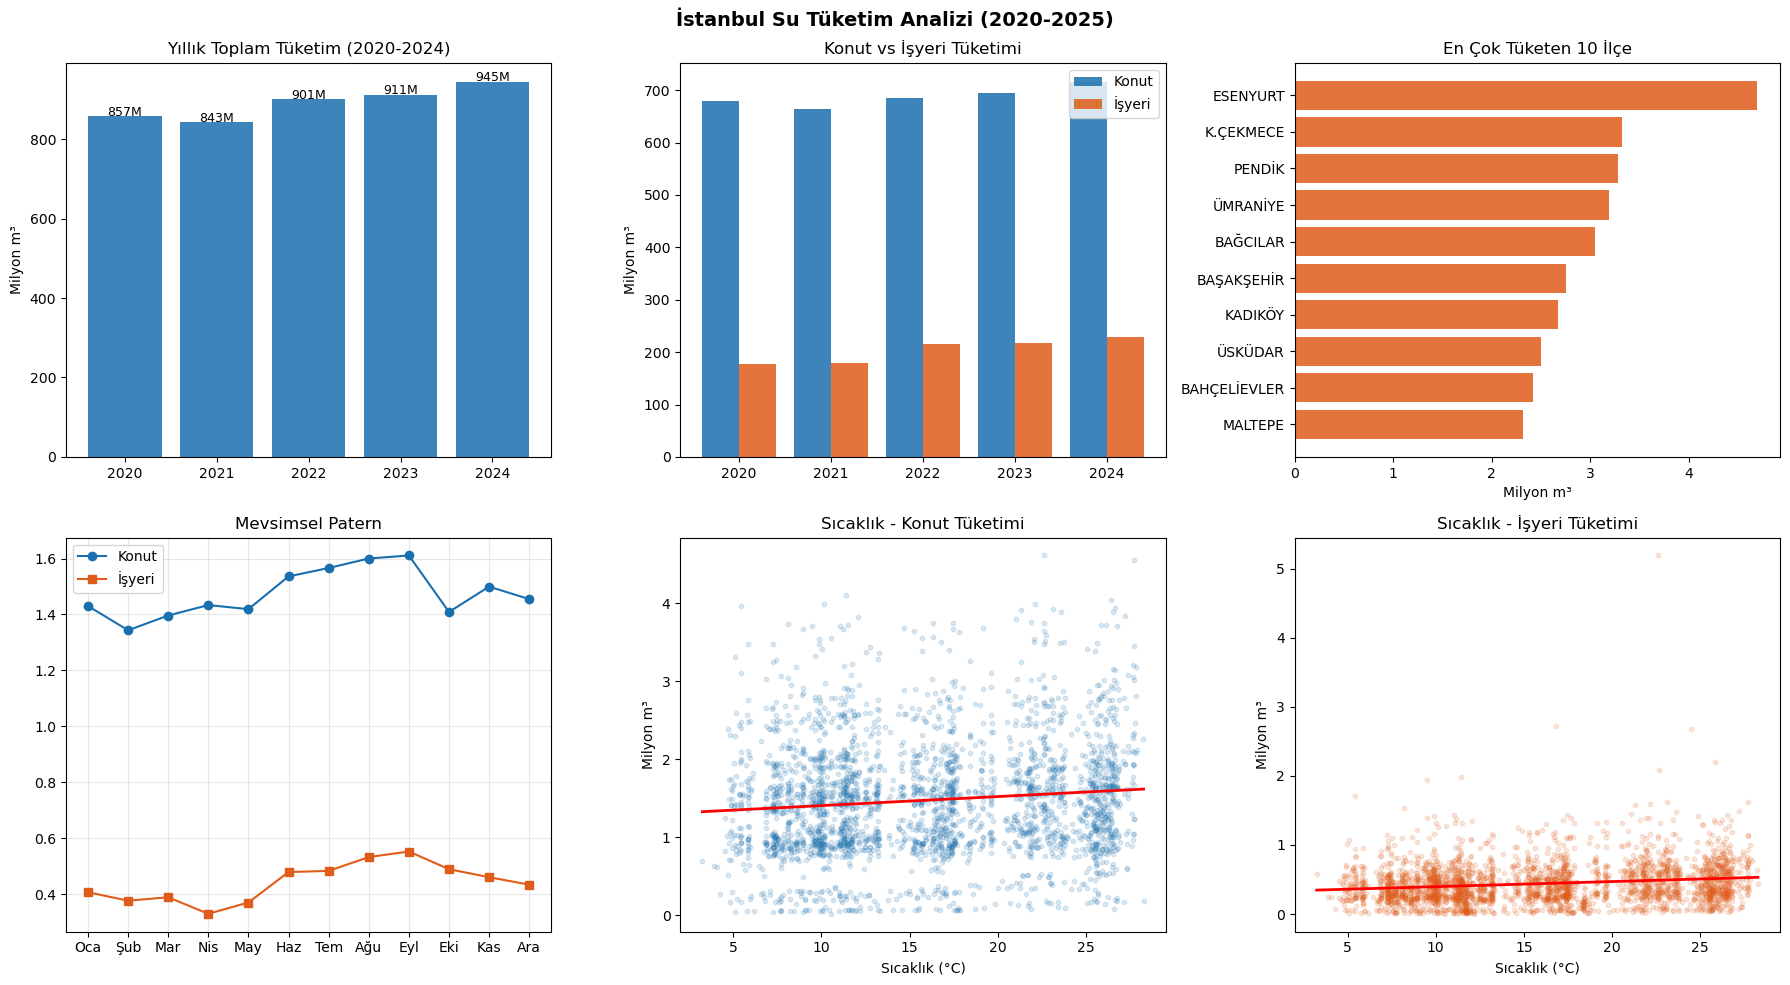

✅ Grafik kaydedildi: analiz.png


In [34]:
# ── AŞAMA 10: KEŞİFÇİ GRAFİKLER ───────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("İstanbul Su Tüketim Analizi (2020-2025)", fontsize=14, fontweight="bold")

# 1. Yıllık toplam
ax1 = axes[0, 0]
yillik_tam = df[df["yil"] < 2025].groupby("yil")["su_tuketimi_m3"].sum() / 1e6

ax1.bar(yillik_tam.index, yillik_tam.values, color="#1a6fae", alpha=0.85)
ax1.set_title("Yıllık Toplam Tüketim (2020-2024)")
ax1.set_ylabel("Milyon m³")
ax1.set_xticks(yillik_tam.index)

for i, v in enumerate(yillik_tam.values):
    ax1.text(yillik_tam.index[i], v + 1, f"{v:.0f}M", ha="center", fontsize=9)

# 2. Konut vs işyeri
ax2 = axes[0, 1]
yillik_konut  = df[df["yil"] < 2025].groupby("yil")["konut_m3"].sum() / 1e6
yillik_isyeri = df[df["yil"] < 2025].groupby("yil")["isyeri_m3"].sum() / 1e6

x = np.arange(len(yillik_konut))

ax2.bar(x - 0.2, yillik_konut.values, width=0.4, label="Konut", color="#1a6fae", alpha=0.85)
ax2.bar(x + 0.2, yillik_isyeri.values, width=0.4, label="İşyeri", color="#e05c1a", alpha=0.85)

ax2.set_title("Konut vs İşyeri Tüketimi")
ax2.set_ylabel("Milyon m³")
ax2.set_xticks(x)
ax2.set_xticklabels(yillik_konut.index)
ax2.legend()

# 3. İlçeler
ax3 = axes[0, 2]
top10 = ilce_ort.head(10) / 1e6
ax3.barh(top10.index[::-1], top10.values[::-1], color="#e05c1a", alpha=0.85)
ax3.set_title("En Çok Tüketen 10 İlçe")
ax3.set_xlabel("Milyon m³")

# 4. Mevsimsellik
ax4 = axes[1, 0]
aylik_konut  = df.groupby("ay")["konut_m3"].mean() / 1e6
aylik_isyeri = df.groupby("ay")["isyeri_m3"].mean() / 1e6

ay_isimleri = ["Oca","Şub","Mar","Nis","May","Haz","Tem","Ağu","Eyl","Eki","Kas","Ara"]

ax4.plot(aylik_konut.index, aylik_konut.values, color="#1a6fae", marker="o", label="Konut")
ax4.plot(aylik_isyeri.index, aylik_isyeri.values, color="#e05c1a", marker="s", label="İşyeri")

ax4.set_title("Mevsimsel Patern")
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(ay_isimleri)
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Sıcaklık - Konut (DÜZELTİLDİ)
ax5 = axes[1, 1]

x1 = pd.to_numeric(df["sicaklik_c"], errors="coerce")
y1 = pd.to_numeric(df["konut_m3"], errors="coerce") / 1e6

mask1 = np.isfinite(x1) & np.isfinite(y1)
x1, y1 = x1[mask1], y1[mask1]

ax5.scatter(x1, y1, alpha=0.15, color="#1a6fae", s=10)
ax5.set_title("Sıcaklık - Konut Tüketimi")
ax5.set_xlabel("Sıcaklık (°C)")
ax5.set_ylabel("Milyon m³")

if len(x1) > 1:
    z = np.polyfit(x1, y1, 1)
    xp = np.linspace(x1.min(), x1.max(), 100)
    ax5.plot(xp, np.poly1d(z)(xp), color="red", linewidth=2)

# ─────────────────────────────
# 6. Sıcaklık - İşyeri (DÜZELTİLDİ)
# ─────────────────────────────

ax6 = axes[1, 2]

x2 = pd.to_numeric(df["sicaklik_c"], errors="coerce")
y2 = pd.to_numeric(df["isyeri_m3"], errors="coerce") / 1e6

mask2 = np.isfinite(x2) & np.isfinite(y2)
x2, y2 = x2[mask2], y2[mask2]

ax6.scatter(x2, y2, alpha=0.15, color="#e05c1a", s=10)
ax6.set_title("Sıcaklık - İşyeri Tüketimi")
ax6.set_xlabel("Sıcaklık (°C)")
ax6.set_ylabel("Milyon m³")

if len(x2) > 1:
    z2 = np.polyfit(x2, y2, 1)
    xp2 = np.linspace(x2.min(), x2.max(), 100)
    ax6.plot(xp2, np.poly1d(z2)(xp2), color="red", linewidth=2)

# ─────────────────────────────

plt.tight_layout()
plt.savefig("analiz.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Grafik kaydedildi: analiz.png")

In [35]:
# ── AŞAMA 11: XGBoost İÇİN ÖZELLİK MÜHENDİSLİĞİ ──────────
#LightGBM ile tamamen aynı özellik seti kullanılır:
#lag, rolling, takvim, exogenous, ilce_id
#Bu sayede iki modelin sonuçları karşılaştırılabilir.

LAG_ADIMLAR     = [1, 2, 3, 6, 12]
ROLLING_PENCERE = [3, 6, 12]
EXOG_COLS       = ["sicaklik_c", "konut_abone", "isyeri_abone"]

def ozellik_ekle(df_in):
    df_out = df_in.sort_values(["unique_id", "ds"]).copy()

    # Lag özellikleri
    for lag in LAG_ADIMLAR:
        df_out[f"lag_{lag}"] = df_out.groupby("unique_id")["y"].shift(lag)

    # Rolling istatistikler
    for p in ROLLING_PENCERE:
        df_out[f"roll_mean_{p}"] = (
            df_out.groupby("unique_id")["y"]
            .transform(lambda x: x.shift(1).rolling(p, min_periods=1).mean())
        )
        df_out[f"roll_std_{p}"] = (
            df_out.groupby("unique_id")["y"]
            .transform(lambda x: x.shift(1).rolling(p, min_periods=1).std().fillna(0))
        )
        df_out[f"roll_max_{p}"] = (
            df_out.groupby("unique_id")["y"]
            .transform(lambda x: x.shift(1).rolling(p, min_periods=1).max())
        )

    # Takvim özellikleri
    df_out["ay"]       = df_out["ds"].dt.month
    df_out["yil"]      = df_out["ds"].dt.year
    df_out["ceyrek"]   = df_out["ds"].dt.quarter
    df_out["mevsim"]   = df_out["ay"].map(
        {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3}
    )
    df_out["ay_sin"]   = np.sin(2 * np.pi * df_out["ay"] / 12)
    df_out["ay_cos"]   = np.cos(2 * np.pi * df_out["ay"] / 12)
    df_out["yil_norm"] = (df_out["yil"] - 2020) / 5

    return df_out


def xgb_hazirla(df, hedef_col, context_bitis="2024-12-01"):
    df_fmt = df[["ilce", "tarih", hedef_col] + EXOG_COLS].copy()
    df_fmt = df_fmt.rename(columns={"ilce":"unique_id", "tarih":"ds", hedef_col:"y"})

    # Eksik tarihleri tamamla
    tam_tarih = pd.date_range(start="2020-01-01", end=df_fmt["ds"].max(), freq="MS")
    parcalar  = []
    for ilce in df_fmt["unique_id"].unique():
        p = df_fmt[df_fmt["unique_id"] == ilce].set_index("ds").reindex(tam_tarih)
        p["unique_id"] = ilce
        p.index.name   = "ds"
        p = p.reset_index()
        for col in ["y"] + EXOG_COLS:
            p[col] = p[col].interpolate(method="linear").ffill().bfill()
        parcalar.append(p)
    df_fmt = pd.concat(parcalar).reset_index(drop=True)

    # İlçe label encoding
    le = LabelEncoder()
    df_fmt["ilce_id"] = le.fit_transform(df_fmt["unique_id"])

    # Özellik mühendisliği
    df_fmt = ozellik_ekle(df_fmt)

    df_ctx = df_fmt[df_fmt["ds"] <= context_bitis].copy()
    df_val = df_fmt[df_fmt["ds"] >  context_bitis].copy()

    return df_fmt, df_ctx, df_val, le


df_full_konut,  df_ctx_konut,  df_val_konut,  le_konut  = xgb_hazirla(df, "konut_m3")
df_full_isyeri, df_ctx_isyeri, df_val_isyeri, le_isyeri = xgb_hazirla(df, "isyeri_m3")

print(f"✅ Konut   bağlam: {df_ctx_konut['ds'].min().strftime('%Y-%m')} → {df_ctx_konut['ds'].max().strftime('%Y-%m')}")
print(f"✅ İşyeri  bağlam: {df_ctx_isyeri['ds'].min().strftime('%Y-%m')} → {df_ctx_isyeri['ds'].max().strftime('%Y-%m')}")
print(f"✅ Validasyon     : {df_val_konut['ds'].min().strftime('%Y-%m')} → {df_val_konut['ds'].max().strftime('%Y-%m')}")

✅ Konut   bağlam: 2020-01 → 2024-12
✅ İşyeri  bağlam: 2020-01 → 2024-12
✅ Validasyon     : 2025-01 → 2025-12


In [36]:
# ── AŞAMA 12: XGBoost MODEL EĞİTİMİ ───────────────────────
#XGBoost vs LightGBM temel parametre farkları:
#max_depth     → LightGBM'in num_leaves karşılığı
#subsample     → LightGBM'in bagging_fraction
#colsample_bytree → LightGBM'in feature_fraction
#reg_alpha     → L1 regularization
#reg_lambda    → L2 regularization
#tree_method="hist" → histogram tabanlı hızlı algoritma

LAG_COLS = [f"lag_{l}" for l in LAG_ADIMLAR]

ROLL_COLS = (
    [f"roll_mean_{p}" for p in ROLLING_PENCERE] +
    [f"roll_std_{p}"  for p in ROLLING_PENCERE] +
    [f"roll_max_{p}"  for p in ROLLING_PENCERE]
)

TAKVIM_COLS = [
    "ay",
    "yil",
    "ceyrek",
    "mevsim",
    "ay_sin",
    "ay_cos",
    "yil_norm"
]

FEATURE_COLS = (
    LAG_COLS +
    ROLL_COLS +
    TAKVIM_COLS +
    EXOG_COLS +
    ["ilce_id"]
)

print(f"📊 Toplam özellik sayısı: {len(FEATURE_COLS)}")


# ── XGBoost Parametreleri ─────────────────────────────────

XGB_PARAMS = {
    "objective"              : "reg:absoluteerror",
    "eval_metric"            : "mae",

    "n_estimators"           : 1000,
    "learning_rate"          : 0.05,

    "max_depth"              : 6,
    "min_child_weight"       : 5,

    "subsample"              : 0.8,
    "colsample_bytree"       : 0.8,

    "reg_alpha"              : 0.1,
    "reg_lambda"             : 1.0,

    "tree_method"            : "hist",

    "early_stopping_rounds"  : 50,

    "random_state"           : 42,
    "verbosity"              : 0,
}


# ── MODEL EĞİTİM FONKSİYONU ──────────────────────────────

def xgb_egit(df_ctx, feature_cols, etiket=""):

    # Eksik değerleri temizle
    df_temiz = df_ctx.dropna(
        subset=feature_cols + ["y"]
    ).copy()

    X = df_temiz[feature_cols]
    y = df_temiz["y"]

    # Zaman sırası korunarak split
    kesim = int(len(df_temiz) * 0.85)

    X_train = X.iloc[:kesim]
    X_val   = X.iloc[kesim:]

    y_train = y.iloc[:kesim]
    y_val   = y.iloc[kesim:]

    # Model oluştur
    model = xgb.XGBRegressor(**XGB_PARAMS)

    # Eğit
    model.fit(
        X_train,
        y_train,

        eval_set=[
            (X_val, y_val)
        ],

        verbose=False
    )

    # Validation MAE
    val_mae = (
        model.evals_result()
        ["validation_0"]["mae"]
        [model.best_iteration]
    )

    print(
        f"✅ {etiket} modeli eğitildi — "
        f"{model.best_iteration} ağaç, "
        f"val MAE: {val_mae:,.0f}"
    )

    return model


# ── MODELLERİ EĞİT ───────────────────────────────────────

model_konut = xgb_egit(
    df_ctx_konut,
    FEATURE_COLS,
    "Konut"
)

model_isyeri = xgb_egit(
    df_ctx_isyeri,
    FEATURE_COLS,
    "İşyeri"
)

📊 Toplam özellik sayısı: 25
✅ Konut modeli eğitildi — 345 ağaç, val MAE: 90,362
✅ İşyeri modeli eğitildi — 408 ağaç, val MAE: 44,123


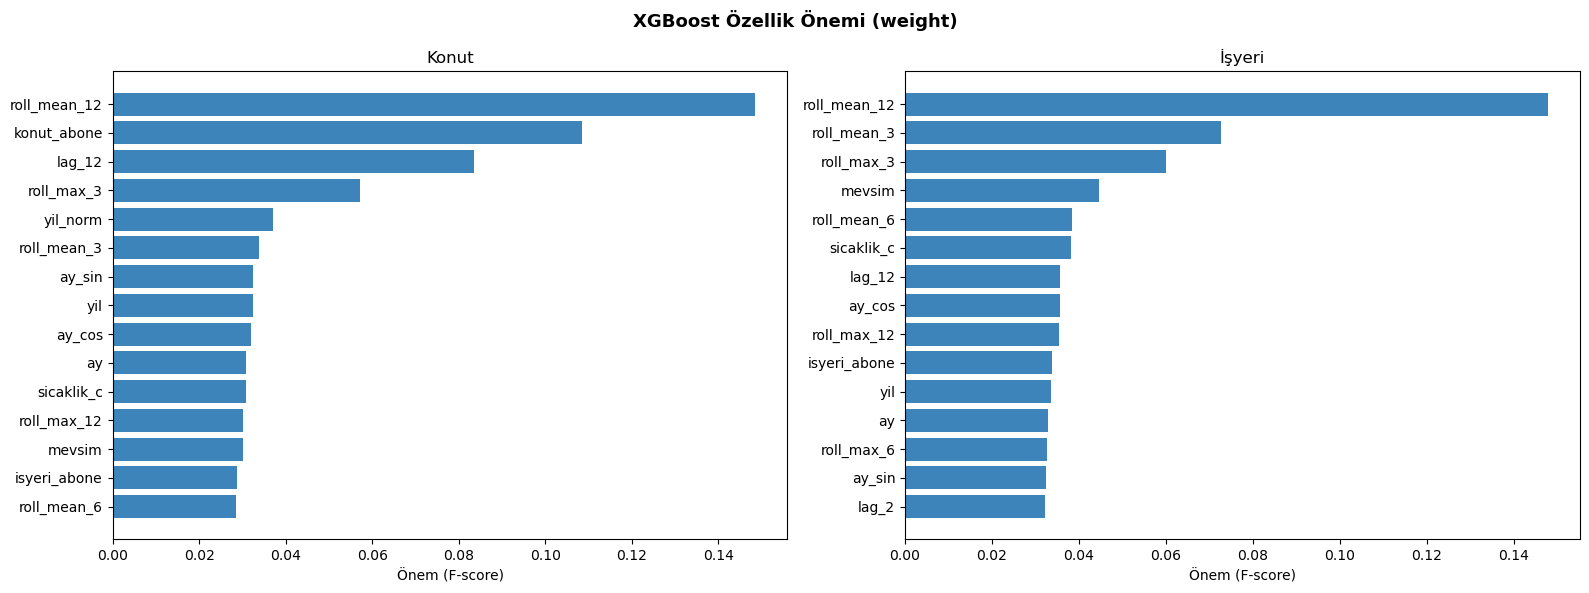

✅ Özellik önemi grafiği kaydedildi


In [37]:
# ── AŞAMA 13: ÖZELLİK ÖNEMİ GRAFİĞİ ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("XGBoost Özellik Önemi (weight)", fontsize=13, fontweight="bold")

for ax, model, baslik in zip(axes,
                              [model_konut, model_isyeri],
                              ["Konut", "İşyeri"]):
    imp = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=True).tail(15)
    ax.barh(imp.index, imp.values, color="#1a6fae", alpha=0.85)
    ax.set_title(baslik)
    ax.set_xlabel("Önem (F-score)")

plt.tight_layout()
plt.savefig("ozellik_onemi_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Özellik önemi grafiği kaydedildi")

In [38]:
# ── AŞAMA 14: RECURSİVE TAHMİN FONKSİYONU ─────────────────
#
# LightGBM ile tamamen aynı recursive strateji:
#   t+1 tahmin → lag buffer'a ekle → t+2 tahmin → ... → t+10
# Exogenous (sıcaklık, abone): validasyon verisinden alınır

def recursive_tahmin(model, df_full, df_val, le, feature_cols, h=10, etiket=""):
    sonuclar = []
    ilceler  = df_full["unique_id"].unique()
    print(f"⏳ {etiket} XGBoost recursive tahmini başlıyor — {len(ilceler)} ilçe...")

    for ilce in ilceler:
        ilce_data = (
            df_full[df_full["unique_id"] == ilce]
            .sort_values("ds").copy()
        )
        ilce_val = (
            df_val[df_val["unique_id"] == ilce]
            .sort_values("ds").head(h)
            .reset_index(drop=True)
        )

        y_buffer       = ilce_data["y"].tolist()
        tahmin_listesi = []

        for adim in range(h):
            tahmin_tarihi = ilce_val["ds"].iloc[adim]
            ay  = tahmin_tarihi.month
            yil = tahmin_tarihi.year

            # Lag değerleri
            lag_vals = {}
            for lag in LAG_ADIMLAR:
                lag_vals[f"lag_{lag}"] = y_buffer[-lag] if len(y_buffer) >= lag else np.nan

            # Rolling istatistikler
            roll_vals = {}
            for p in ROLLING_PENCERE:
                pencere_data = y_buffer[-p:] if len(y_buffer) >= p else y_buffer
                roll_vals[f"roll_mean_{p}"] = np.mean(pencere_data)
                roll_vals[f"roll_std_{p}"]  = np.std(pencere_data) if len(pencere_data) > 1 else 0
                roll_vals[f"roll_max_{p}"]  = np.max(pencere_data)

            # Exogenous (validasyondan)
            exog_vals = {col: ilce_val[col].iloc[adim] for col in EXOG_COLS}

            # Takvim
            takvim_vals = {
                "ay"      : ay,
                "yil"     : yil,
                "ceyrek"  : (ay - 1) // 3 + 1,
                "mevsim"  : {12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3}[ay],
                "ay_sin"  : np.sin(2 * np.pi * ay / 12),
                "ay_cos"  : np.cos(2 * np.pi * ay / 12),
                "yil_norm": (yil - 2020) / 5,
            }

            satir  = {**lag_vals, **roll_vals, **takvim_vals, **exog_vals,
                      "ilce_id": le.transform([ilce])[0]}
            X_pred = pd.DataFrame([satir])[feature_cols]

            pred = float(model.predict(X_pred)[0])
            pred = max(pred, 0)

            tahmin_listesi.append(pred)
            y_buffer.append(pred)

        ilce_df = pd.DataFrame({
            "unique_id" : ilce,
            "ds"        : ilce_val["ds"].values[:h],
            "tahmin"    : tahmin_listesi,
        })
        sonuclar.append(ilce_df)

    print(f"✅ {etiket} tahmini tamamlandı")
    return pd.concat(sonuclar).reset_index(drop=True)

print("✅ Recursive tahmin fonksiyonu tanımlandı")

✅ Recursive tahmin fonksiyonu tanımlandı


In [39]:
# ── AŞAMA 15: XGBoost TAHMİNİ — KONUT ─────────────────────
tahmin_konut_raw = recursive_tahmin(
    model        = model_konut,
    df_full      = df_full_konut,
    df_val       = df_val_konut,
    le           = le_konut,
    feature_cols = FEATURE_COLS,
    h            = 12,
    etiket       = "Konut"
)
tahmin_konut = tahmin_konut_raw.rename(columns={"tahmin": "konut_tahmin"})
print(f"✅ Konut tahmini: {tahmin_konut.shape[0]} satır")

⏳ Konut XGBoost recursive tahmini başlıyor — 39 ilçe...
✅ Konut tahmini tamamlandı
✅ Konut tahmini: 468 satır


In [40]:
# ── AŞAMA 16: XGBoost TAHMİNİ — İŞYERİ ────────────────────
tahmin_isyeri_raw = recursive_tahmin(
    model        = model_isyeri,
    df_full      = df_full_isyeri,
    df_val       = df_val_isyeri,
    le           = le_isyeri,
    feature_cols = FEATURE_COLS,
    h            = 12,
    etiket       = "İşyeri"
)
tahmin_isyeri = tahmin_isyeri_raw.rename(columns={"tahmin": "isyeri_tahmin"})
print(f"✅ İşyeri tahmini: {tahmin_isyeri.shape[0]} satır")

⏳ İşyeri XGBoost recursive tahmini başlıyor — 39 ilçe...
✅ İşyeri tahmini tamamlandı
✅ İşyeri tahmini: 468 satır


In [41]:
# ── AŞAMA 17: TAHMİNLERİ BİRLEŞTİR ────────────────────────
tahminler = tahmin_konut.merge(tahmin_isyeri, on=["unique_id", "ds"], how="inner")
tahminler["toplam_tahmin"] = tahminler["konut_tahmin"] + tahminler["isyeri_tahmin"]

print(f"✅ Tahminler birleştirildi: {tahminler.shape[0]} satır")
print(tahminler.head())

✅ Tahminler birleştirildi: 468 satır
  unique_id         ds  konut_tahmin  isyeri_tahmin  toplam_tahmin
0    ADALAR 2025-01-01  60511.406250   21914.779297   82426.185547
1    ADALAR 2025-02-01  59695.824219    9227.381836   68923.206055
2    ADALAR 2025-03-01  59959.921875    3980.215332   63940.137207
3    ADALAR 2025-04-01  66727.890625   25437.513672   92165.404297
4    ADALAR 2025-05-01  65629.054688   22640.505859   88269.560547


In [42]:
# ── AŞAMA 18: PERFORMANS DEĞERLENDİRMESİ ───────────────────
gercek_k = df_val_konut[["unique_id",  "ds", "y"]].rename(columns={"y": "konut_gercek"})
gercek_i = df_val_isyeri[["unique_id", "ds", "y"]].rename(columns={"y": "isyeri_gercek"})
gercek   = gercek_k.merge(gercek_i, on=["unique_id", "ds"])
gercek["toplam_gercek"] = gercek["konut_gercek"] + gercek["isyeri_gercek"]

karsilastirma = tahminler.merge(gercek, on=["unique_id", "ds"], how="inner")

def mape_hesapla(gercek, tahmin):
    return (gercek - tahmin).abs() / gercek.abs() * 100

karsilastirma["mape_konut"]  = mape_hesapla(karsilastirma["konut_gercek"],  karsilastirma["konut_tahmin"])
karsilastirma["mape_isyeri"] = mape_hesapla(karsilastirma["isyeri_gercek"], karsilastirma["isyeri_tahmin"])
karsilastirma["mape_toplam"] = mape_hesapla(karsilastirma["toplam_gercek"], karsilastirma["toplam_tahmin"])

karsilastirma["abs_konut"]   = (karsilastirma["konut_gercek"]  - karsilastirma["konut_tahmin"]).abs()
karsilastirma["abs_isyeri"]  = (karsilastirma["isyeri_gercek"] - karsilastirma["isyeri_tahmin"]).abs()
karsilastirma["abs_toplam"]  = (karsilastirma["toplam_gercek"] - karsilastirma["toplam_tahmin"]).abs()

metrikler = (
    karsilastirma
    .groupby("unique_id")
    .agg(
        MAPE_Konut  = ("mape_konut",  "mean"),
        MAPE_Isyeri = ("mape_isyeri", "mean"),
        MAPE_Toplam = ("mape_toplam", "mean"),
        MAE_Konut   = ("abs_konut",   "mean"),
        MAE_Isyeri  = ("abs_isyeri",  "mean"),
        MAE_Toplam  = ("abs_toplam",  "mean"),
        RMSE_Konut  = ("abs_konut",   lambda x: np.sqrt((x**2).mean())),
        RMSE_Isyeri = ("abs_isyeri",  lambda x: np.sqrt((x**2).mean())),
        RMSE_Toplam = ("abs_toplam",  lambda x: np.sqrt((x**2).mean())),
    )
    .reset_index()
    .sort_values("MAPE_Toplam")
)

print("\n📊 İLÇE BAZLI PERFORMANS:")
print(metrikler.to_string(index=False))
print(f"\n🎯 Ort. MAPE  Konut  : {metrikler['MAPE_Konut'].mean():.2f}%")
print(f"🎯 Ort. MAPE  İşyeri : {metrikler['MAPE_Isyeri'].mean():.2f}%")
print(f"🎯 Ort. MAPE  Toplam : {metrikler['MAPE_Toplam'].mean():.2f}%")
print(f"🎯 Ort. MAE   Toplam : {metrikler['MAE_Toplam'].mean():,.0f} m³")
print(f"🎯 Ort. RMSE  Toplam : {metrikler['RMSE_Toplam'].mean():,.0f} m³")


📊 İLÇE BAZLI PERFORMANS:
   unique_id  MAPE_Konut  MAPE_Isyeri  MAPE_Toplam     MAE_Konut    MAE_Isyeri    MAE_Toplam    RMSE_Konut   RMSE_Isyeri   RMSE_Toplam
  BAYRAMPAŞA    5.772255    10.141767     4.525836  44546.179167  30361.959375  50556.045833  66828.716455  40948.212470  68633.676429
    ÇEKMEKÖY    4.996449    12.863047     5.581818  61212.326042  30451.972396  80990.623958  77532.934897  36743.034227  96182.898707
BAHÇELİEVLER    6.362092     8.198271     5.644194 112940.085417  34861.358333 119989.487500 154229.237872  44801.413988 177789.439923
    ESENYURT    5.116420    12.096283     5.722423 158194.429167 161773.303125 267785.748958 258968.506729 215034.306890 350044.915813
  SANCAKTEPE    6.745764     7.469188     6.270656 120354.162500  24654.409635 132481.263802 151436.294813  30311.194705 168291.354461
    BEŞİKTAŞ    6.773157     6.722717     6.291145  49142.644792  35198.828646  78533.394271  59654.432612  50406.945788 103564.848720
   K.ÇEKMECE    5.687497    1

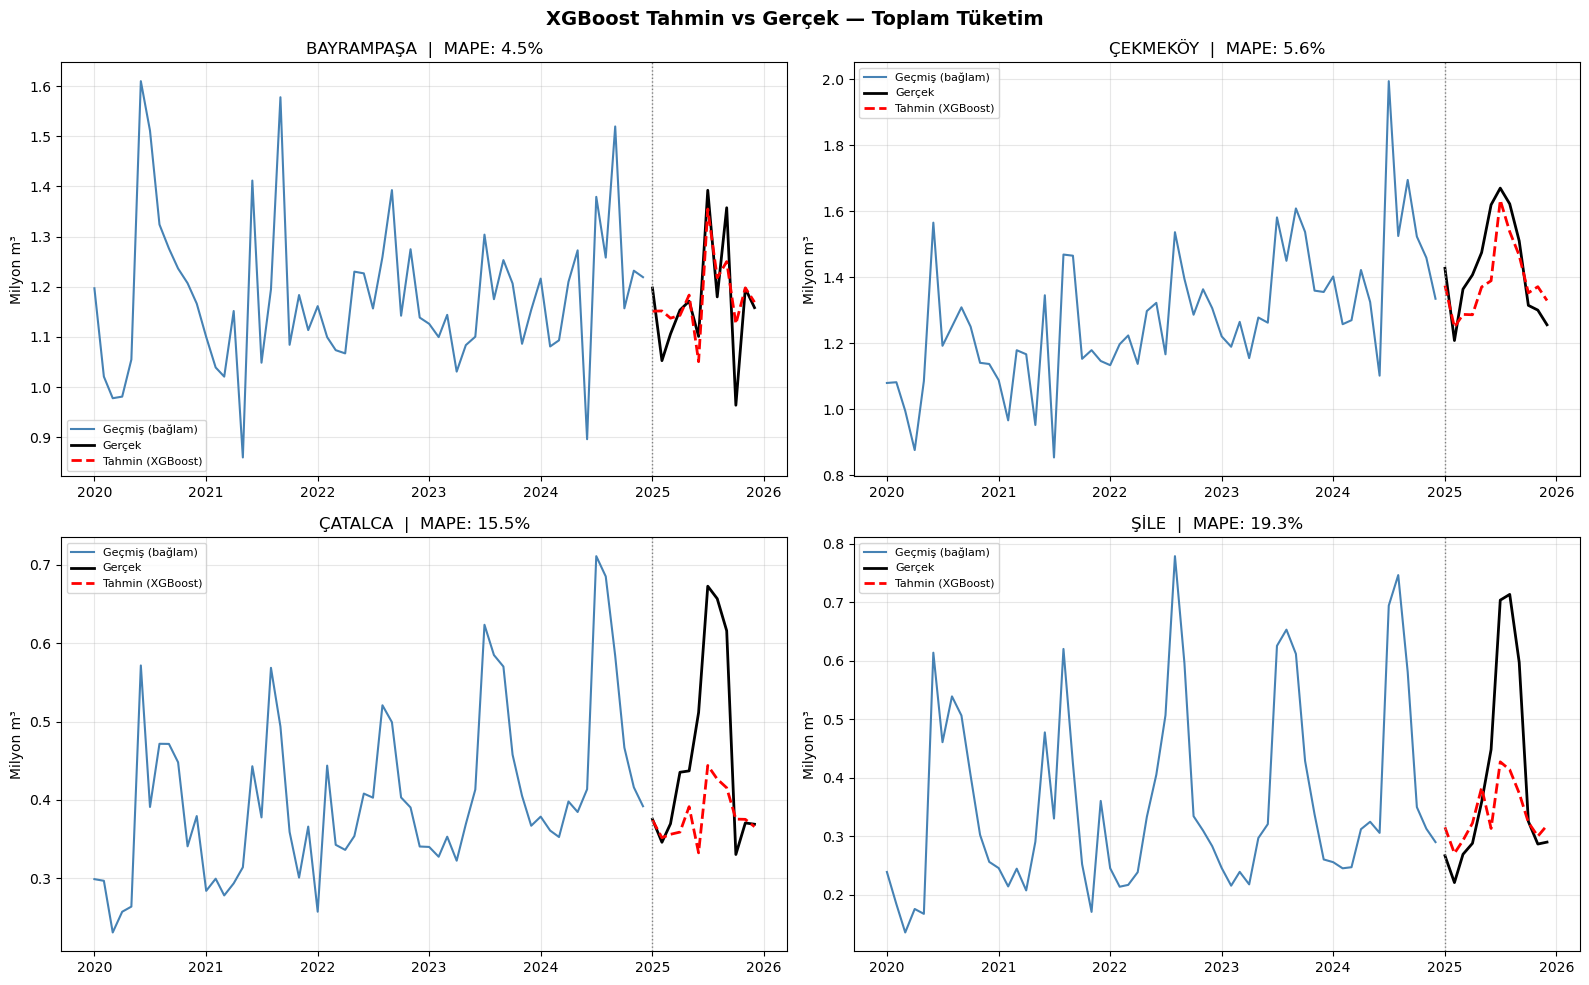

✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_xgb.png


In [43]:
# ── AŞAMA 19: TAHMİN GRAFİKLERİ ────────────────────────────
en_iyi  = metrikler.head(2)["unique_id"].tolist()
en_kotu = metrikler.tail(2)["unique_id"].tolist()
gosterilecek = en_iyi + en_kotu

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("XGBoost Tahmin vs Gerçek — Toplam Tüketim", fontsize=14, fontweight="bold")

for ax, ilce in zip(axes.flatten(), gosterilecek):
    gecmis_k = df_full_konut[df_full_konut["unique_id"]   == ilce].copy()
    gecmis_i = df_full_isyeri[df_full_isyeri["unique_id"] == ilce].copy()
    gecmis_k = gecmis_k[gecmis_k["ds"] <= "2024-12-01"]
    gecmis_i = gecmis_i[gecmis_i["ds"] <= "2024-12-01"]
    gecmis_k = gecmis_k.copy()
    gecmis_k["toplam"] = gecmis_k["y"].values + gecmis_i["y"].values

    k        = karsilastirma[karsilastirma["unique_id"] == ilce]
    mape_val = metrikler[metrikler["unique_id"] == ilce]["MAPE_Toplam"].values[0]

    ax.plot(gecmis_k["ds"], gecmis_k["toplam"] / 1e6,
            color="steelblue", linewidth=1.5, label="Geçmiş (bağlam)")
    ax.plot(k["ds"], k["toplam_gercek"] / 1e6,
            color="black", linewidth=2, label="Gerçek")
    ax.plot(k["ds"], k["toplam_tahmin"] / 1e6,
            color="red", linewidth=2, linestyle="--", label="Tahmin (XGBoost)")
    ax.axvline(pd.Timestamp("2025-01-01"), color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ilce}  |  MAPE: {mape_val:.1f}%")
    ax.set_ylabel("Milyon m³")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tahmin_grafikleri_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_xgb.png")

In [44]:
# ── AŞAMA 20: SONUÇLARI EXCEL'E KAYDET ─────────────────────
CIKTI_DOSYASI = r"C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_xgb.xlsx"

with pd.ExcelWriter(CIKTI_DOSYASI, engine="openpyxl") as writer:
    karsilastirma.to_excel(writer, sheet_name="Tahmin vs Gerçek",  index=False)
    metrikler.to_excel(    writer, sheet_name="Performans",         index=False)
    tahminler.to_excel(    writer, sheet_name="Tahminler",          index=False)
    df_ctx_konut.to_excel( writer, sheet_name="Bağlam Konut",      index=False)
    df_ctx_isyeri.to_excel(writer, sheet_name="Bağlam İşyeri",     index=False)
    df.to_excel(           writer, sheet_name="Ham Veri",           index=False)

print(f"✅ Excel kaydedildi: {CIKTI_DOSYASI}")
print("\n🎉 Tüm işlem tamamlandı! (XGBoost)")

✅ Excel kaydedildi: C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_xgb.xlsx

🎉 Tüm işlem tamamlandı! (XGBoost)
